In [1]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
#from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html
import matplotlib.patches as patches
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

from matplotlib.colors import LinearSegmentedColormap

# Defina um mapa de cores personalizado para criar o degradê
cmap = LinearSegmentedColormap.from_list('custom', ['orange', 'orange', 'darkorange', 'darkorange'], N=256)

from altaipony.ffd import FFD, generate_random_power_law_distribution
import matplotlib.pyplot as plt

for att in ['axes.labelsize', 'axes.titlesize', 'legend.fontsize',
            'legend.fontsize', 'xtick.labelsize', 'ytick.labelsize']:
    plt.rcParams[att] = 14


/home/paola/anaconda3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/paola/.lightkurve/cache. Please move all the files in the legacy directory /home/paola/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [2]:
#### Parametros do setor 1 ######
data=np.loadtxt('parametros_setor1.txt')
dur=data[:,0]
sub=data[:,1]
des=data[:,2]
ampl=data[:,3]
ener = data[:,4]
#### Parametros do setor 27 2Min ######
data2=np.loadtxt('par_setor27_2Min.txt')
dur2=data2[:,0]
sub2=data2[:,1]
des2=data2[:,2]
ampl2=data2[:,3]
ener2 = data2[:,4]
#### Parametros do setor 27 20s ######
data3=np.loadtxt('par_setor27_20s.txt')
dur3=data3[:,0]
sub3=data3[:,1]
des3=data3[:,2]
ampl3=data3[:,3]
ener3= data3[:,4]
print(ener3)

[2.45916e+32 2.11667e+32 3.65317e+32 6.27081e+33 8.07592e+32 1.32363e+32
 8.29914e+32 7.53556e+31 4.68724e+31 8.73481e+31 4.42280e+32 3.01060e+33
 4.00186e+31 7.17323e+31 3.88171e+31 1.02342e+32 1.22956e+33 8.71834e+32
 1.60268e+32 4.41632e+32 1.59266e+32 5.99602e+32 6.72049e+31 4.58150e+32
 1.06829e+33 4.24721e+33 2.13187e+32 1.10374e+34 3.39906e+33 1.21516e+33
 2.70666e+32 9.50105e+31 2.03081e+33 1.56246e+34 1.37250e+32 3.42373e+33
 2.75021e+32 1.06233e+32 1.21275e+33 1.25799e+33 4.13262e+31 7.40244e+31
 3.43904e+32]


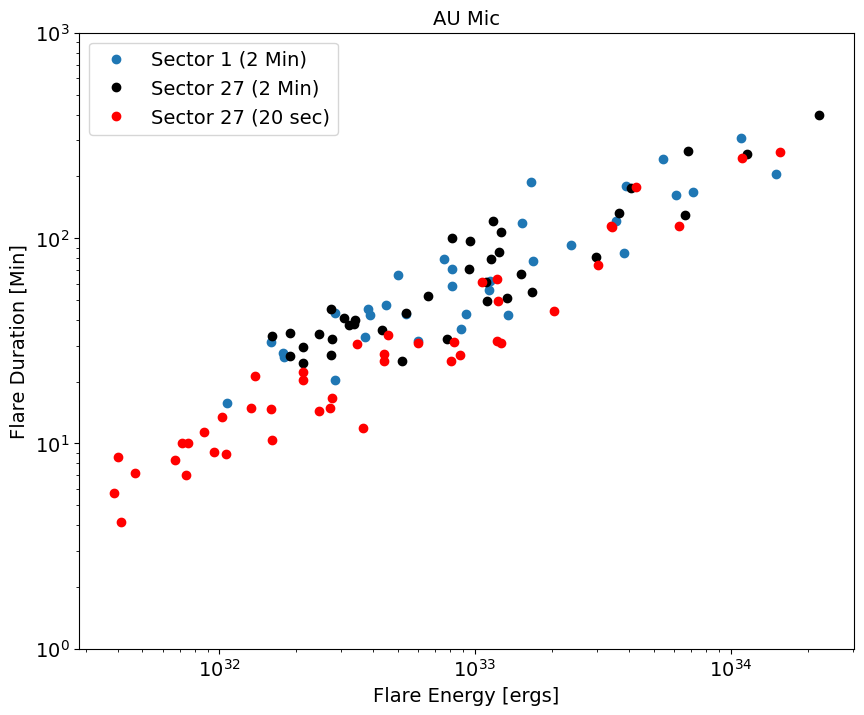

In [3]:
## Definindo eixo x para as energias
x_s1 = ener
x_s27 = ener2
x_s27_20s = ener3
# Definindo o eixo y para a duração 
y_s1 = dur
y_s27 = dur2
y_s27_20s = dur3
plt.figure(figsize=(10, 8))

plt.yscale('log')
plt.xscale('log')
plt.plot(x_s1, y_s1, 'o', label = 'Sector 1 (2 Min)')
plt.plot(x_s27, y_s27, 'ko', label = 'Sector 27 (2 Min)')
plt.plot(x_s27_20s, y_s27_20s, 'ro', label = 'Sector 27 (20 sec)')
plt.ylim(1e0,1e3)
#plt.xlim(1e28,1e37)
plt.title('AU Mic')
plt.xlabel("Flare Energy [ergs]")
plt.ylabel("Flare Duration [Min]")
plt.legend()
plt.show()

In [4]:

x = []
ene = []
tamanho = [np.log10]
count=0
for j in range(11):
    count=0
    ene.append(32+j*0.2)
    for i in range(len(ener)):
        if (32.2+(j*0.2))>np.log10(ener[i]) and np.log10(ener[i])>(32+(j*0.2)):
            count+=1
    x.append(count)

x2 = []
ene2 = []
count2=0
for j in range(11):
    count2 = 0
    ene2.append(32.2+j*0.2)
    for i in range(len(ener2)):
        if (32.4+(j*0.2))>np.log10(ener2[i]) and np.log10(ener2[i])>(32.2+(j*0.2)):
            count2+=1
    x2.append(count2)

x3 = []
ene3 = []
count3=0
for j in range(14):
    count3 = 0
    ene3.append(31.4+j*0.2)
    for i in range(len(ener3)):
        if (31.6+(j*0.2))>np.log10(ener3[i]) and np.log10(ener3[i])>(31.4+(j*0.2)):
            count3+=1
    x3.append(count3)


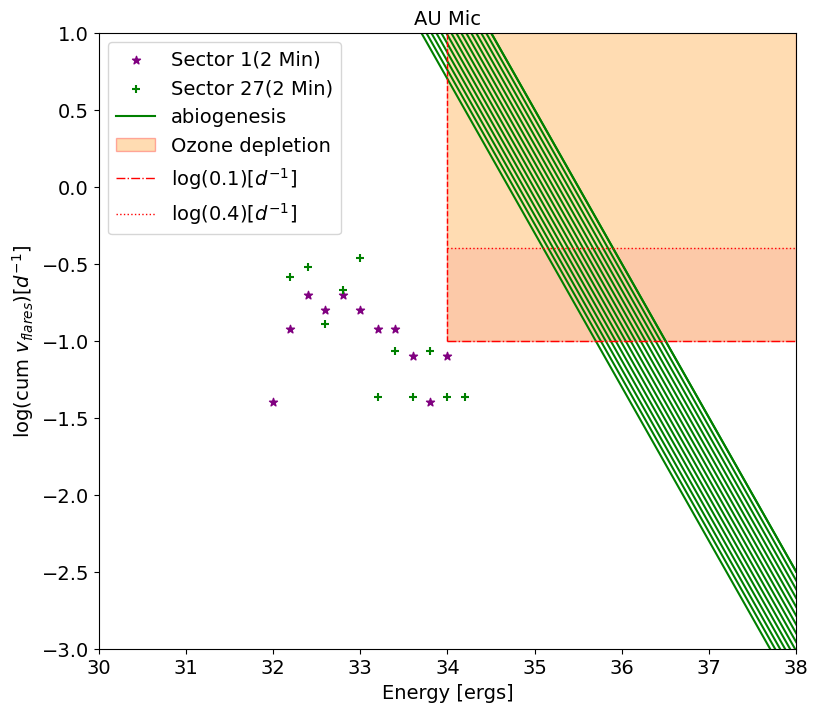

[32.0, 32.2, 32.4, 32.6, 32.8, 33.0, 33.2, 33.4, 33.6, 33.8, 34.0]


In [14]:
x_y = np.array(x)/25.131
x_y2 = np.array(x2)/23.307
x_y3 = np.array(x3)/23.307
intercept = 0
slope = -(4/3)
x_01 = [i for i in np.linspace(32,38,1000)]

import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Exemplo de dados de entrada e saída
X =np.array(ene2)
y =np.array(np.log10(x_y2))
# Use linregress para ajustar o modelo linear
slope, intercept, r_value, p_value, std_err = linregress(X, y)

# Faça previsões para os valores existentes de X
predictions = slope*X + intercept

# Exemplo de dados de entrada e saída
X2 =np.array(ene)
y2 =np.array(np.log10(x_y))
# Use linregress para ajustar o modelo linear
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(X2, y2)

# Faça previsões para os valores existentes de X
predictions2 = slope2*X2 + intercept2





############### Gráficos ##################
plt.figure(figsize=(9, 8))
plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='purple', marker = '*')
plt.scatter((ene2),np.log10(x_y2), label = 'Sector 27(2 Min)', c='green', marker = '+')
#plt.scatter((ene3),np.log10(x_y3),label = 'Sector 27(20 sec)',c='black', marker = '^')
for i in np.linspace(37.7,38.5,15):
    y_01 = [-(1)*x_01[j] +(((i)-3)) for j in range(len(x_01))]
    plt.plot(x_01,y_01,color = 'green')
plt.plot(x_01,y_01,color = 'green', label = 'abiogenesis')

# Adicione um quadrado (retângulo) com cores diferentes para as áreas claras e escuras
square = patches.Rectangle((34, -1), 4, 4, linewidth=1, edgecolor='red', facecolor='darkorange', alpha=0.3,label='Ozone depletion')
plt.gca().add_patch(square)

# Crie um retângulo menor para a área mais clara
light_orange = patches.Rectangle((34, -1), 4, 0.6, linewidth=1, edgecolor='none', facecolor='lightcoral', alpha=0.2)
plt.gca().add_patch(light_orange)

plt.plot([34, 38], [-1, -1], color='red', linestyle='-.', linewidth=1, label='log(0.1)[$d^{-1}$]')
plt.plot([34, 38], [-0.4, -0.4], color='red', linestyle=':', linewidth=1 ,label='log(0.4)[$d^{-1}$]')
plt.plot([34, 34], [-1, 1], color='red', linestyle='--', linewidth=1)


#plt.plot((ene),x_y, label = 'Sector 1(2 Min)' )
#plt.plot((ene2),x_y2, label = 'Sector 27(2 Min)')
#plt.plot((ene3),x_y3,label = 'Sector 27(20 sec)')
plt.legend()
#plt.ylim(-1.5,0)
#plt.xlim(31.5,34.5)
plt.ylim(-3.0,1)
plt.xlim(30,38)
plt.title('AU Mic')
plt.xlabel("Energy [ergs]")
plt.ylabel("log(cum $v_{flares}$)[$d^{-1}$]");
#plt.yscale('log')
plt.show()
print(ene)

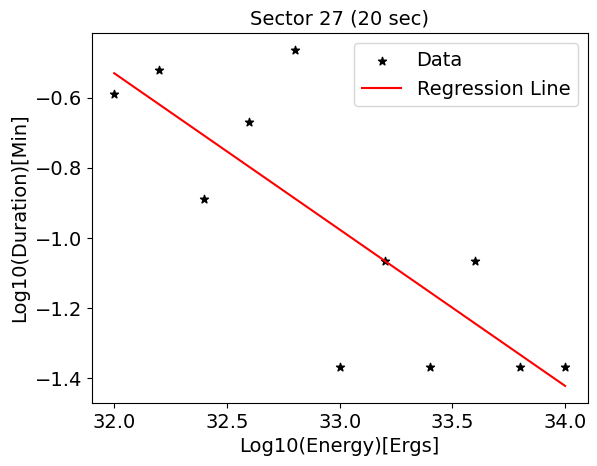

Coeficiente Angular (Slope): -0.44542828132464984
Coeficiente Linear (Intercept): 13.722964228252339
Coeficiente de Correlação (r): -0.8046565941565719
Valor-p (p-value): 0.002817759265209111
Erro Padrão (Standard Error): 0.1095576284505751


In [13]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Exemplo de dados de entrada e saída
X =np.array(ene)
y =np.array(np.log10(x_y2))
# Use linregress para ajustar o modelo linear
slope, intercept, r_value, p_value, std_err = linregress(X, y)

# Faça previsões para os valores existentes de X
predictions = slope*X + intercept

# Plote os dados originais e a linha de regressão
plt.scatter(X, y, label='Data', color='black', marker="*")
plt.plot(X, predictions, label='Regression Line', color='red')
plt.ylabel('Log10(Duration)[Min]')
plt.xlabel('Log10(Energy)[Ergs]')
plt.legend()
plt.title('Sector 27 (20 sec)')
plt.show()

# Imprima os coeficientes e outras estatísticas
print(f"Coeficiente Angular (Slope): {slope}")
print(f"Coeficiente Linear (Intercept): {intercept}")
print(f"Coeficiente de Correlação (r): {r_value}")
print(f"Valor-p (p-value): {p_value}")
print(f"Erro Padrão (Standard Error): {std_err}")

